# Beam search
Exact and fuzzy beam search for approximating WFSA intersection.

## TO-DO
- JITify beam search

## Done
- Implement exact beam search
- Implement fuzzy beam search
- Profile fuzzy beam search vs. edit graph intersection

In [3]:
import pynini
import numpy as np
from typing import NamedTuple
from dataclasses import dataclass
import graphviz

## Data preparation utilities

In [4]:
ascii_table = pynini.SymbolTable()
ascii_table.add_symbol("<eps>")

symbol_range = (1, 256)

for i in range(*symbol_range):
    ascii_table.add_symbol(chr(i))

In [5]:
def set_symbols(fst: pynini.Fst):
    fst.set_input_symbols(ascii_table)
    fst.set_output_symbols(ascii_table)
    return fst

def print_fst(f):
    f=set_symbols(f)
    tmp_path = '/tmp/null.dot'
    f.draw(tmp_path, portrait=True)
    with open(tmp_path) as file:
        return graphviz.Source(file.read())

In [6]:
lexicon = [
    "foo",
    "fee",
    "ffoo",
    "bar",
    "boar",
    "fbar",
]

In [7]:
def generate_random_word(word_len: int | None = None) -> str:
    alpha_start = ord("a")
    alpha_end = ord("z")

    if word_len is None:
        min_word_len = 3
        max_word_len = 10
        word_len = np.random.randint(
            low=min_word_len, high=max_word_len, size=(1,)
        ).item()

    random_ints = np.random.randint(low=alpha_start, high=alpha_end, size=(word_len,))
    random_word = "".join(chr(i) for i in random_ints)
    return random_word


random_wordlist = [generate_random_word() for _ in range(10)]

random_wordlist[:10]

['bvbdcjk',
 'vcdlacaj',
 'cha',
 'sicfttrsc',
 'ivvq',
 'cbfcwkj',
 'qdgyp',
 'aawgs',
 'wbjk',
 'xkjuvcp']

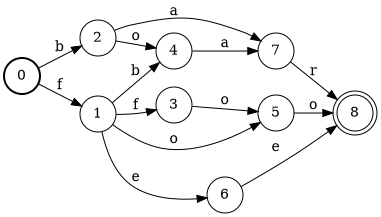

In [8]:
L = pynini.union(*lexicon)
L.set_input_symbols(ascii_table)
L.optimize()
L

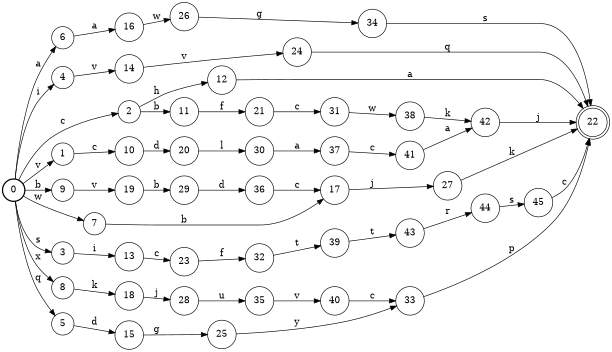

In [9]:
Lrand = pynini.union(*random_wordlist)
Lrand.set_input_symbols(ascii_table)
Lrand.optimize()
Lrand

In [10]:
def get_random_lexicon(num_words: int) -> pynini.Fst:
    wordlist = [generate_random_word() for _ in range(num_words)]
    lexicon = pynini.union(*wordlist)
    lexicon.optimize()
    return lexicon

## FST $\mapsto$ Compressed Sparse Row
Used by beam search functions

In [11]:
# moved to module `src/beam_search.py`

from src.beam_search import WfsaCsr, WfsaCsrBeam

In [12]:
WfsaCsr.from_pynini(L)

WfsaCsr(offsets=array([ 0,  2,  4,  8,  9, 10, 11, 12, 13, 13], dtype=int32), next_states=array([1, 2, 3, 4, 4, 5, 6, 7, 8, 3, 8, 7, 8], dtype=int32), weights=array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32), labels=array([ 98, 102,  97, 111,  98, 101, 102, 111, 114,  97, 101, 111, 111],
      dtype=int32), final=array([False, False, False, False, False, False, False, False,  True]))

## Beam search implementation

In [13]:
from src.beam_search import (
    decode_beam,
    get_next_beams,
    get_next_beams_fuzzy,
    intersect_beam,
    filter_repeat_beams,
)

Demo beam search

In [14]:
bar = pynini.accep("bar")
bar_csr = WfsaCsr.from_pynini(bar)

L_csr = WfsaCsr.from_pynini(L)
result = intersect_beam(bar_csr, L_csr)
[decode_beam(beam) for beam in result]

[('bar', 0.0)]

In [15]:
baar = pynini.accep("baar")
baar_csr = WfsaCsr.from_pynini(baar)

result = intersect_beam(baar_csr, L_csr, fuzzy_search=True)
[decode_beam(beam) for beam in result]

[('bar', 1.0), ('boar', 1.0), ('bar', 1.0), ('bar', 2.0), ('bar', 3.0)]

In [16]:
Lrand_csr = WfsaCsr.from_pynini(Lrand)

result = intersect_beam(baar_csr, Lrand_csr, fuzzy_search=True, num_beam=10)
[decode_beam(beam) for beam in result]

[('aawgs', 4.0),
 ('aawgs', 4.0),
 ('aawgs', 4.0),
 ('aawgs', 5.0),
 ('aawgs', 5.0),
 ('aawgs', 5.0),
 ('aawgs', 5.0),
 ('bvbdcjk', 6.0),
 ('bvbdcjk', 6.0),
 ('bvbdcjk', 7.0)]

## Test vanilla vs. jit beam search

In [17]:
Lrand_csr = WfsaCsr.from_pynini(Lrand)

result = intersect_beam(
    baar_csr, Lrand_csr, fuzzy_search=True, num_beam=10, use_jit=True
)
[decode_beam(beam) for beam in result]

[('aawgs', 4.0),
 ('aawgs', 4.0),
 ('aawgs', 4.0),
 ('aawgs', 5.0),
 ('aawgs', 5.0),
 ('aawgs', 5.0),
 ('aawgs', 5.0),
 ('bvbdcjk', 7.0),
 ('bvbdcjk', 7.0),
 ('bvbdcjk', 8.0)]

## Fuzzy search with edit graphs
Pynini-native fuzzy search.

In [18]:
from pynini.lib.edit_transducer import EditTransducer
from pynini.lib.rewrite import lattice_to_nshortest, lattice_to_strings
from string import ascii_lowercase

In [19]:
edit_transducer = EditTransducer(alphabet=ascii_lowercase, bound=5)

In [20]:
def decode_lattice(lattice: pynini.Fst) -> list[tuple[str, float]]:
    result = []

    path_iter = lattice.paths()
    while not path_iter.done():
        label_iter = path_iter.olabels()
        label_chars = [ascii_table.find(label) for label in label_iter if label != 0]
        label_str = "".join(label_chars)
        weight = float(path_iter.weight())
        result.append((label_str, weight))
        path_iter.next()

    result.sort(key=lambda t: t[-1])
    return result

In [21]:
def get_search_graph(lexicon: pynini.Fst) -> pynini.Fst:
    search_graph = edit_transducer._e_o @ lexicon
    search_graph.optimize()
    return search_graph

In [22]:
def get_query_graph(query_str: pynini.Fst) -> pynini.Fst:
    query_graph = query_str @ edit_transducer._e_i
    query_graph.optimize()
    return query_graph

In [23]:
def intersect_graphs(
    query_graph: pynini.FstLike, search_graph: pynini.Fst, top_k: int = 5
) -> list[tuple[str, float]]:
    lattice = query_graph @ search_graph
    lattice = lattice.project("output")
    lattice.optimize()
    top_k_lattice = lattice_to_nshortest(lattice, nshortest=top_k)
    result = decode_lattice(top_k_lattice)
    return result

Demo cases

In [24]:
search_graph = get_search_graph(Lrand)
query_graph = get_query_graph("baar")

intersect_graphs(query_graph, search_graph)

[('cha', 3.0), ('wbjk', 4.0), ('ivvq', 4.0), ('aawgs', 4.0), ('qdgyp', 5.0)]

## Profiling
Split profiling into lexicon preprocessing, query preprocessing and execution.
Assume lexicon/query $\mapsto$ FST already taken care of, as this is the same for both strategies.

**Beam search:**
- Lexicon preprocessing: `WfsaCsr.from_pynini()` on Lexicon FST
- Query preprocessing: `WfsaCsr.from_pynini()` on query string
- Execution: `intersect_beam(left, right, fuzzy_search=True)`

**Edit graph intersection:**
- Lexicon preprocessing: `search_graph = edit_transducer._e_o @ lexicon`
- Query preprocessing: `query_graph = query_str @ edit_transducer._e_i`
- Execution: `pynini.shortest_path(search_graph@query_graph)`

In [25]:
import time
from typing import Any

def time_execution(funct: callable) -> tuple[float, Any]:
    start = time.perf_counter()
    result = funct()
    end = time.perf_counter()

    duration = end-start
    return duration, result

In [26]:
def profile_beam_search(
    lexicon: pynini.Fst,
    query: str,
    top_k: int = 5,
    unique_only: bool = True,
) -> dict[str, Any]:
    # lexicon preprocessing
    lexicon_preproc_time, lexicon_csr = time_execution(
        lambda: WfsaCsr.from_pynini(lexicon)
    )

    # query preprocessing
    def preproc_query():
        query_fsa = pynini.accep(query)
        query_csr = WfsaCsr.from_pynini(query_fsa)
        return query_csr

    query_preproc_time, query_csr = time_execution(preproc_query)

    # search
    def execute_search():
        results = intersect_beam(
            query_csr,
            lexicon_csr,
            num_beam=top_k,
            fuzzy_search=True,
            unique_only=unique_only,
        )
        return results
    def execute_search_jit():
        results = intersect_beam(
            query_csr,
            lexicon_csr,
            num_beam=top_k,
            fuzzy_search=True,
            unique_only=unique_only,
            use_jit=True,
        )
        return results

    search_time, search_results = time_execution(execute_search)
    search_time_jit, _ = time_execution(execute_search_jit)

    total_time = lexicon_preproc_time + query_preproc_time + search_time

    decoded_results = [decode_beam(beam) for beam in search_results]

    return {
        "search_strategy": "beam_search_fuzzy",
        "lexicon_preproc_time": lexicon_preproc_time,
        "query_preproc_time": query_preproc_time,
        "search_time": search_time,
        "search_time_jit": search_time_jit,
        "total_time": total_time,
        "results": decoded_results,
    }

In [27]:
def profile_graph_search(lexicon: pynini.Fst, query: str, top_k: int = 5) -> dict[str, Any]:
    # lexicon preprocessing
    lexicon_preproc_time, search_graph = time_execution(
        lambda: get_search_graph(lexicon)
    )

    # query preprocessing
    def preproc_query():
        query_graph = get_query_graph(query)
        return query_graph

    query_preproc_time, query_graph = time_execution(preproc_query)

    # search
    def execute_search():
        results = intersect_graphs(query_graph, search_graph, top_k=top_k)
        return results

    search_time, search_results = time_execution(execute_search)

    total_time = lexicon_preproc_time + query_preproc_time + search_time

    return {
        "search_strategy": "edit_graph_search",
        "lexicon_preproc_time": lexicon_preproc_time,
        "query_preproc_time": query_preproc_time,
        "search_time": search_time,
        "total_time": total_time,
        "results": search_results,
    }

In [28]:
lexicon = get_random_lexicon(2000)
query = "foo"

profile_beam_search(lexicon, query)

{'search_strategy': 'beam_search_fuzzy',
 'lexicon_preproc_time': 0.012066642000718275,
 'query_preproc_time': 0.00017742700038070325,
 'search_time': 0.0007274500003404683,
 'search_time_jit': 0.04952748299911036,
 'total_time': 0.012971519001439447,
 'results': [('fofr', 2.0),
  ('foeip', 3.0),
  ('fogfnr', 4.0),
  ('fofuswbuw', 7.0),
  ('fojcxoslt', 7.0)]}

In [29]:
profile_graph_search(lexicon, query)

{'search_strategy': 'edit_graph_search',
 'lexicon_preproc_time': 0.16121120199932193,
 'query_preproc_time': 0.0001867869996203808,
 'search_time': 0.10034893600095529,
 'total_time': 0.2617469249998976,
 'results': [('tof', 2.0),
  ('ubo', 2.0),
  ('eof', 2.0),
  ('bto', 2.0),
  ('qfyo', 2.0)]}

## Profile visualization
Get time metrics at various lexicon sizes, beam widths, edit bounds, etc.

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

In [31]:
time_rows = []

# reverse for pyschological benefit
# (loop speeds up as it progresses instead of slowing down)
lexicon_sizes = np.arange(500, 10_000, 500)[::-1]
query_sizes = [5, 10, 15]
beam_sizes = [1, 5, 50, 500, 1_000, 5_000]

for size in tqdm(lexicon_sizes):
    lexicon = get_random_lexicon(size)
    num_states = lexicon.num_states()
    for query_len in query_sizes:
        query = generate_random_word()[:query_len]

        graph_result = profile_graph_search(lexicon, query, top_k=20)
        time_rows.append(
            {
                **graph_result,
                "num_words": size,
                "num_states": num_states,
                "query_len": query_len,
            }
        )

        for num_beam in beam_sizes:
            beam_result = profile_beam_search(lexicon, query, top_k=num_beam, unique_only=True)

            # beam search may miss some results due to pruning
            # calculate recall based on graph search results
            graph_results_set = set(graph_result["results"])
            beam_results_set = set(beam_result["results"])
            recall = (
                len(graph_results_set.intersection(beam_results_set))
                / len(graph_results_set)
                if graph_results_set
                else 1.0
            )

            time_rows.append(
                {
                    **beam_result,
                    "num_words": size,
                    "num_states": num_states,
                    "query_len": query_len,
                    "recall": recall,
                    "num_beam": num_beam,
                }
            )

time_df = pd.DataFrame(time_rows)
time_df.head()

100%|██████████| 19/19 [01:57<00:00,  6.18s/it]


,search_strategy,lexicon_preproc_time,query_preproc_time,search_time,total_time,results,num_words,num_states,query_len,search_time_jit,recall,num_beam
0,edit_graph_search,0.820978,0.000410,0.487817,1.309204,"[(tqu, 1.0), (jql, 1.0), (jxu, 1.0), (jru, 1.0...",9500,13462,5,NaN,NaN,NaN
1,beam_search_fuzzy,0.045885,0.000233,0.000320,0.046439,"[(jqutcel, 4.0)]",9500,13462,5,0.049487,0.00,1.0
2,beam_search_fuzzy,0.044584,0.000217,0.000917,0.045718,"[(jquvit, 3.0), (jqecqc, 4.0), (jqutcel, 4.0),...",9500,13462,5,0.048766,0.00,5.0
3,beam_search_fuzzy,0.043810,0.000217,0.006078,0.050104,"[(jql, 1.0), (jau, 1.0), (jru, 1.0), (jxu, 1.0...",9500,13462,5,0.050476,0.30,50.0
4,beam_search_fuzzy,0.045113,0.000222,0.037275,0.082610,"[(jql, 1.0), (jau, 1.0), (jru, 1.0), (jxu, 1.0...",9500,13462,5,0.119274,0.45,500.0


In [32]:
def prepare_df_for_plotting(time_df: pd.DataFrame) -> pd.DataFrame:
    # melt df so that we have a single "time_seconds" and "search_stage" column for plotting
    time_df = time_df.melt(
        id_vars=[
            "search_strategy",
            "num_words",
            "num_states",
            "query_len",
            "num_beam",
            "recall",
        ],
        value_vars=[
            "lexicon_preproc_time",
            "query_preproc_time",
            "search_time",
            "search_time_jit",
        ],
        var_name="search_stage",
        value_name="time_seconds",
    )

    # track JIT separately from non-JIT beam search
    jit_mask = (time_df["search_stage"] == "search_time_jit") & (
        time_df["search_strategy"] == "beam_search_fuzzy"
    )
    time_df.loc[jit_mask, "search_strategy"] = "beam_search_fuzzy_jit"

    # merge "search_time_jit" with "search_time"
    time_df.loc[jit_mask, "search_stage"] = "search_time"
    return time_df

In [33]:
plot_df = prepare_df_for_plotting(time_df)
plot_df.head()

,search_strategy,num_words,num_states,query_len,num_beam,recall,search_stage,time_seconds
0,edit_graph_search,9500,13462,5,NaN,NaN,lexicon_preproc_time,0.820978
1,beam_search_fuzzy,9500,13462,5,1.0,0.00,lexicon_preproc_time,0.045885
2,beam_search_fuzzy,9500,13462,5,5.0,0.00,lexicon_preproc_time,0.044584
3,beam_search_fuzzy,9500,13462,5,50.0,0.30,lexicon_preproc_time,0.043810
4,beam_search_fuzzy,9500,13462,5,500.0,0.45,lexicon_preproc_time,0.045113


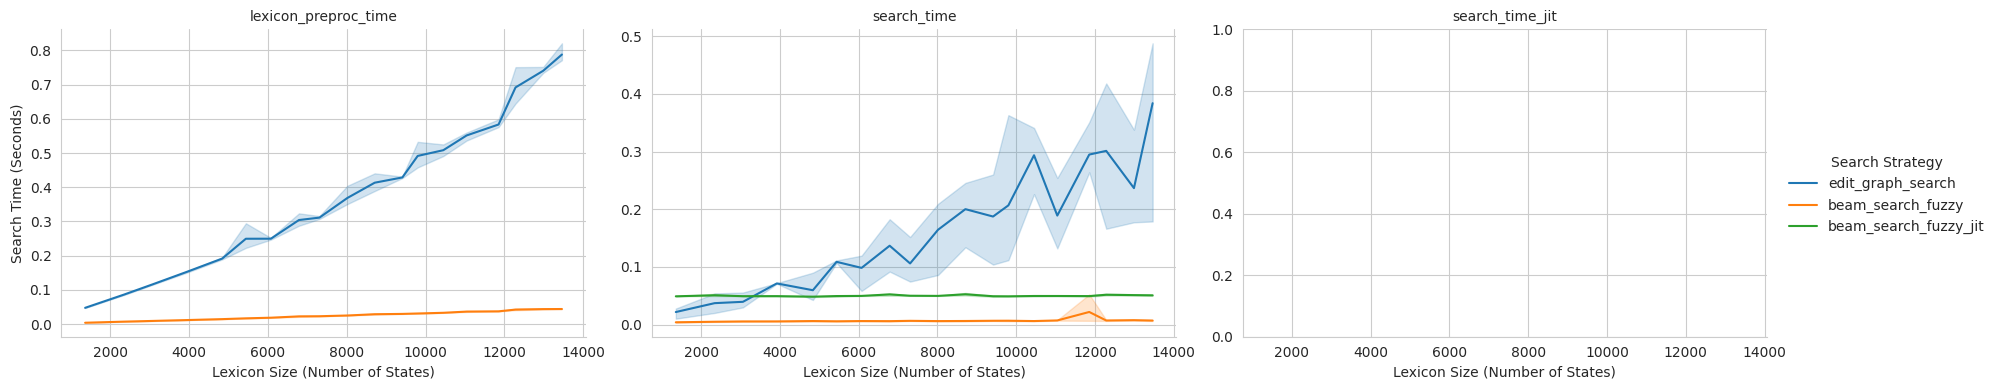

In [45]:
# seaborn lineplot showing search time by lexicon size, with separate colors for beam search and graph search
# and separate facets for lexicon preprocessing and search time (exclude query preprocessing)
# with line style for query length
# fix num_beam=5 for beam search
sns.set_style("whitegrid")
plot_mask = (plot_df["search_stage"] != "query_preproc_time") & (
    (plot_df["search_strategy"] == "edit_graph_search") | (plot_df["num_beam"] == 50)
)
g = sns.FacetGrid(
    plot_df[plot_mask],
    height=4,
    aspect=1.5,
    col="search_stage",
    sharey=False,
)
g.map_dataframe(
    sns.lineplot,
    "num_states",
    "time_seconds",
    hue="search_strategy",
)
g.set_axis_labels("Lexicon Size (Number of States)", "Search Time (Seconds)")
g.set_titles("{col_name}")
g.add_legend(title="Search Strategy")
plt.show()

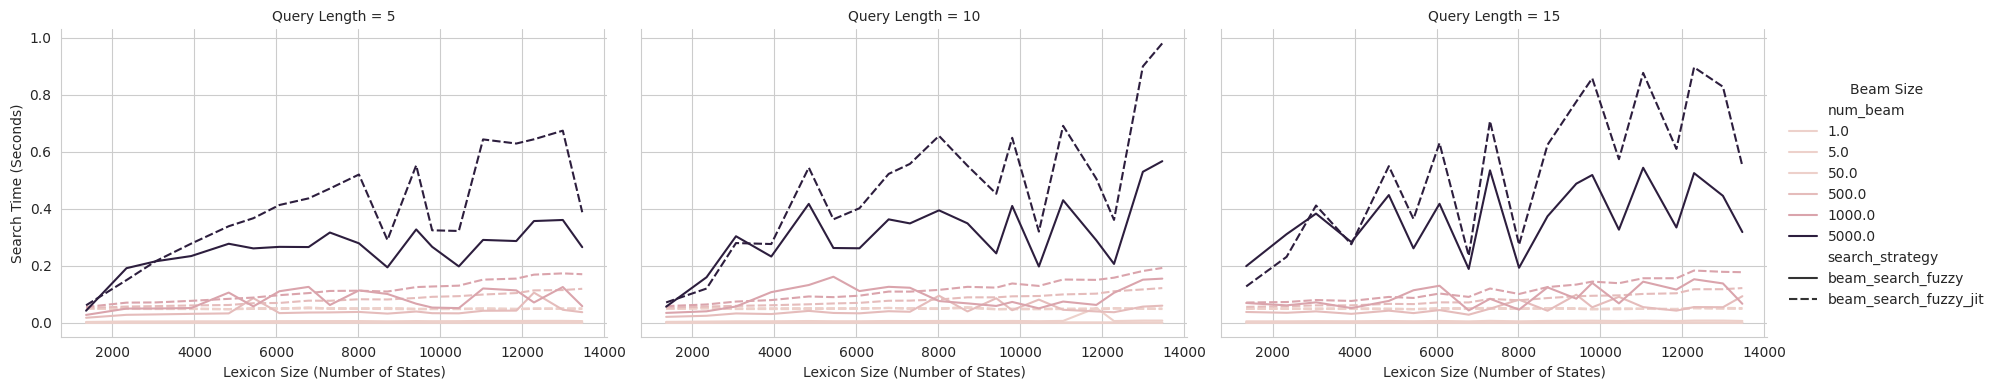

In [50]:
# seaborn lineplot with x-axis as lexicon size and y-axis as search time
# faceted by query length with line color by num_beam, only showing beam search results
# at search stage
sns.set_style("whitegrid")
beam_plot_df = plot_df[
    (plot_df["search_strategy"].isin(["beam_search_fuzzy", "beam_search_fuzzy_jit"]))
    & plot_df["search_stage"].eq("search_time")
]
g = sns.FacetGrid(
    beam_plot_df,
    height=4,
    aspect=1.5,
    col="query_len",
    sharey=True,
)
g.map_dataframe(
    sns.lineplot, "num_states", "time_seconds", hue="num_beam", style="search_strategy"
)
g.set_axis_labels("Lexicon Size (Number of States)", "Search Time (Seconds)")
g.set_titles("Query Length = {col_name}")
g.add_legend(title="Beam Size")
plt.show()

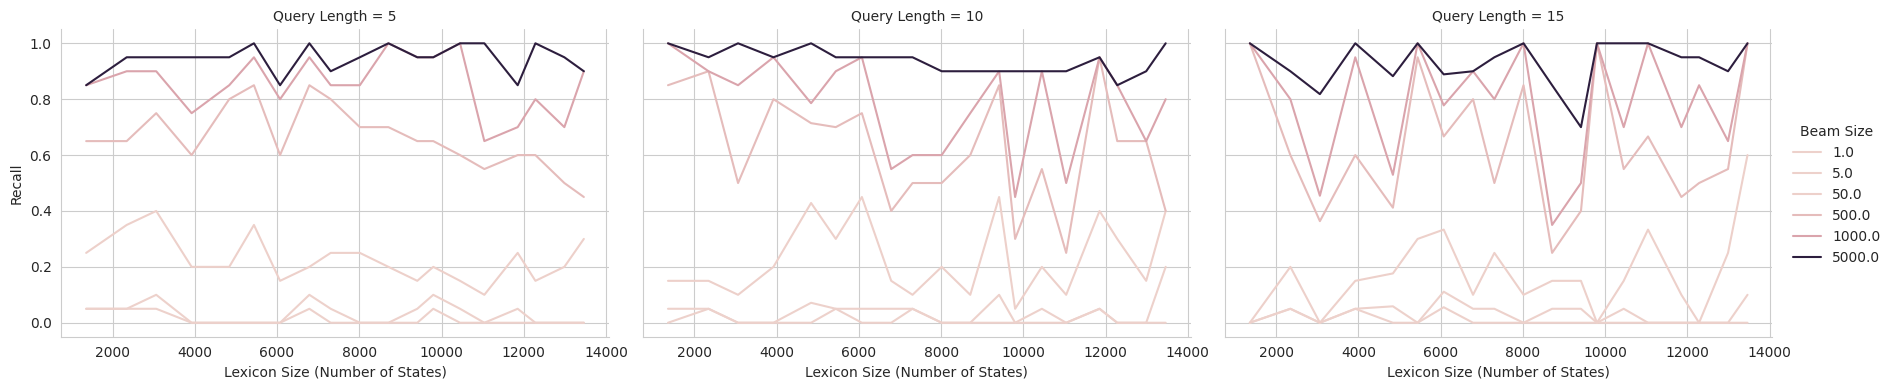

In [36]:
# plot recall by lexicon size, faceted by query length and colored by num_beam, only showing beam search results
sns.set_style("whitegrid")
recall_plot_df = plot_df[
    (plot_df["search_strategy"] == "beam_search_fuzzy")
    & plot_df["search_stage"].eq("search_time")
]
g = sns.FacetGrid(
    recall_plot_df,
    height=4,
    aspect=1.5,
    col="query_len",
    sharey=True,
)
g.map_dataframe(
    sns.lineplot,
    "num_states",
    "recall",
    hue="num_beam",
)
g.set_axis_labels("Lexicon Size (Number of States)", "Recall")
g.set_titles("Query Length = {col_name}")
g.add_legend(title="Beam Size")
plt.show()

## Debugging beam search correctness
Those recall metrics are a bit concerning.
We expect that beam search will miss some hypotheses since we're constraining the search space considered, but the fact that we can get as low as 20% recall with 500 beams is surprising.
Let's test fuzzy beam search with tiny transducers.

In [37]:
def compare_graph_beam(test: str | list[str] | pynini.Fst, query: str) -> dict[str, list[tuple[str, float]]]:
    if type(test) is str:
        test = pynini.accep(test)
    elif isinstance(test, list):
        test = pynini.union(*test)
    graph_out = profile_graph_search(test, query)['results']
    beam_out = profile_beam_search(test, query)['results']

    return {
        "graph_out": graph_out,
        "beam_out": beam_out,
    }

In [38]:
# beam and graph search both handle insertion

test = "foo"
query = "ffffoo"

compare_graph_beam(test, query)

{'graph_out': [('foo', 3.0)], 'beam_out': [('foo', 3.0)]}

In [39]:
# beam and graph search both handle deletion

test = "foo"
query = ""

compare_graph_beam(test, query)

{'graph_out': [('foo', 3.0)], 'beam_out': [('foo', 3.0)]}

In [40]:
# beam and graph search both handle substitution

test = "foo"
query = "aaa"

compare_graph_beam(test, query)

{'graph_out': [('foo', 3.0)], 'beam_out': [('foo', 3.0)]}

In [41]:

test = ["foo", "bar", "for", "baz"]
query = "forfor"

compare_graph_beam(test, query)

{'graph_out': [('foo', 3.0), ('for', 3.0), ('bar', 5.0)],
 'beam_out': [('for', 3.0), ('foo', 3.0), ('bar', 5.0)]}